# 05_统计检验方法-卡方检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文大家聊聊统计检验方法中的**卡方检验**\~

之前总结了十大统计检验方法，点击这里可以查看。

今天给大家详细的解释一下关于统计检验方法中的**卡方检验**\~

## 直观解释

### 1. 什么是卡方检验？

**卡方检验**（Chi-square test）是一种用于判断分类变量之间是否有统计学上的关联的统计方法。

通俗来说，卡方检验帮助我们回答这样的问题：某些类别之间的差异是偶然的吗？还是有某种关联存在？

**举个简单的例子**：

你想知道喜欢咖啡和喜欢茶的人在男女之间是否有差异。

调查了100个人，记录了他们的性别以及他们是否喜欢咖啡或茶，得到了如下的一个表格：

|  | 喜欢咖啡 | 喜欢茶 | 总数 |
|-|-|-|-|
| 男性 | 30 | 20 | 50 |
| 女性 | 10 | 40 | 50 |
| 总数 | 40 | 60 | 100 |

你想知道，**性别**和**喜欢的饮品**之间是否存在某种关联。也就是说，男性和女性对咖啡和茶的喜好差异大吗？卡方检验就是用来判断这种差异是否具有统计学意义的工具。

### 2. 卡方检验的本质是什么？

**卡方检验的本质**是比较**实际观测到的频率**和**理论上期望的频率**之间的差距，看这种差距是否可以用随机误差解释，还是表明类别之间存在关联。

- **实际频率**：你从数据中实际观察到的结果（比如有多少男性喜欢咖啡）。
- **期望频率**：如果性别和喜好之间没有任何关系，你根据总数和比例预期应该观察到的结果。

如果实际频率和期望频率之间的差距很大，卡方检验会告诉你这可能不是偶然的，性别和喜好可能有关系；如果差距很小，说明这可能只是统计上的随机误差，性别和喜好没有关系。

#### 继续之前的例子：

假设如果性别和喜欢咖啡/茶之间没有关联，那么根据总体比例（50%男性和50%女性），我们应该期望看到：

- 有20名男性喜欢茶（总人数\*茶比例=50×60%），而实际数据中有20人喜欢茶。
- 有30名男性喜欢咖啡（总人数\*咖啡比例=50×40%），实际数据中也是30人喜欢咖啡。

但是，如果观测到的实际数据和期望数据差别较大，卡方检验就会告诉我们这种差异可能不是偶然的。

### 3. 卡方检验的特点

卡方检验有以下几个主要特点：

1. **用于分类数据**：卡方检验专门处理分类变量，如性别、颜色、职业等，而不是连续的数值型变量。
2. **检验类别之间的关联性**：卡方检验可以用于检测两个或多个分类变量是否存在统计学上的关联，比如性别和饮食偏好、职业和健康状况。
3. **基于频率**：卡方检验关注的是每个类别中实际观察到的频数和期望频数之间的差异。
4. **样本量要求较大**：卡方检验在样本量较大的情况下效果较好，因为样本量太小会导致不准确的结果。
5. **非参数检验**：卡方检验不需要数据符合正态分布，因此在很多实际情况中都适用。

卡方检验是一种用于检测分类变量之间关联性的统计工具，核心是比较实际数据与理论期望数据之间的差异，差异越大，说明两个变量之间的关联性越大。

为了直观展示卡方检验中的数据分布形状和特征，我们可以使用**柱状图**或**堆叠条形图**来展示不同类别下实际观测的频率和期望频率。这样更容易对比不同类别间的分布差异，展示性别与饮品偏好之间的关系。

让我为你生成一个对比柱状图。

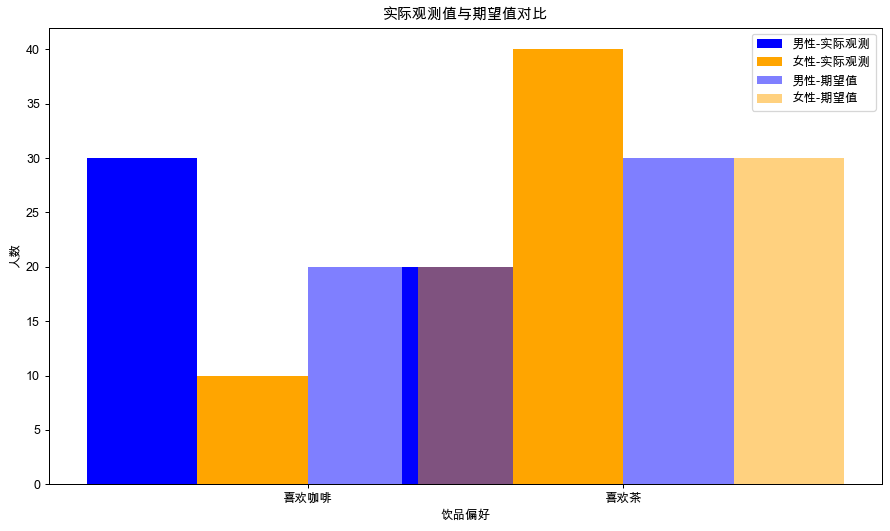

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定义观测值和期望值
observed = [[30, 20],  # 男性喜欢咖啡和茶的实际观测值
            [10, 40]]  # 女性喜欢咖啡和茶的实际观测值

expected = [[20, 30],  # 男性喜欢咖啡和茶的期望值
            [20, 30]]  # 女性喜欢咖啡和茶的期望值

# 数据准备
categories = ['喜欢咖啡', '喜欢茶']
men_observed = observed[0]  # 男性实际观测值
women_observed = observed[1]  # 女性实际观测值
men_expected = expected[0]  # 男性期望值
women_expected = expected[1]  # 女性期望值

# 设置柱状图参数
bar_width = 0.35  # 每个柱子的宽度
index = np.arange(len(categories))  # X轴坐标

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))

# 画出男性和女性的实际观测值
bar1 = ax.bar(index, men_observed, bar_width, label='男性-实际观测', color='blue')
bar2 = ax.bar(index + bar_width, women_observed, bar_width, label='女性-实际观测', color='orange')

# 画出男性和女性的期望频率值
bar3 = ax.bar(index + 2*bar_width, men_expected, bar_width, label='男性-期望值', color='blue', alpha=0.5)
bar4 = ax.bar(index + 3*bar_width, women_expected, bar_width, label='女性-期望值', color='orange', alpha=0.5)

# 设置图表信息
ax.set_xlabel('饮品偏好')
ax.set_ylabel('人数')
ax.set_title('实际观测值与期望值对比')
ax.set_xticks(index + 1.5*bar_width)
ax.set_xticklabels(categories)
ax.legend()

# 显示图表
plt.tight_layout()
plt.show()

上面的图表展示了**男性和女性在实际观测和期望频率上的对比**：

- 蓝色和橙色的深色柱状表示实际观测到的男性和女性对咖啡和茶的偏好。
- 蓝色和橙色的浅色柱状表示期望的频率，即在假设性别和饮品偏好无关联的情况下，预计观测到的结果。

![原文参考图，当前结果见代码输出](attachments/img_011.png)

通过对比这些柱状图，可以直观地看到性别和饮品偏好之间的差异，实际数据与期望频率的偏离程度越大，说明卡方检验的差异越显著。

## 公式推导

卡方检验的公式推导基于实际观测频率与期望频率之间的差异，使用卡方统计量来衡量这种差异。

下面详细讲解卡方检验的公式和推导过程。

### 1. 卡方检验的公式

卡方检验的核心公式是：


$$
\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}
$$


- $O_i$：第 $i$ 类的实际观测频数（Observed frequency）。
- $E_i$：第 $i$ 类的期望频数（Expected frequency）。
- $\chi^2$：卡方统计量（Chi-squared statistic）。

卡方统计量的意义是度量实际观测值和期望值之间的差异，差异越大，卡方统计量就越大。

### 2. 期望频数的计算

在卡方检验中，期望频数 $E_i$是在假设变量之间没有关联的情况下得到的。如果两组变量（如性别和饮品偏好）没有关联，那么期望频数是由**行合计**和**列合计**计算出来的。

计算期望频数的公式为：


$$
E_{ij} = \frac{\text{行合计} \times \text{列合计}}{\text{总计}}
$$


举例来说，在我们之前的性别和饮品偏好表格中：

|  | 喜欢咖啡 | 喜欢茶 | 总数 |
|-|-|-|-|
| 男性 | 30 | 20 | 50 |
| 女性 | 10 | 40 | 50 |
| 总数 | 40 | 60 | 100 |

对于男性喜欢咖啡的期望频数 $E_{11}$：


$$
E_{11} = \frac{(\text{男性总数} \times \text{喜欢咖啡的总数})}{\text{总人数}} = \frac{50 \times 40}{100} = 20
$$


对于女性喜欢咖啡的期望频数 $E_{21}$：


$$
E_{21} = \frac{(\text{女性总数} \times \text{喜欢咖啡的总数})}{\text{总人数}} = \frac{50 \times 40}{100} = 20
$$


对于男性喜欢茶的期望频数 $E_{12}$：


$$
E_{12} = \frac{(\text{男性总数} \times \text{喜欢茶的总数})}{\text{总人数}} = \frac{50 \times 60}{100} = 30
$$


对于女性喜欢茶的期望频数 $E_{22}$：


$$
E_{22} = \frac{(\text{女性总数} \times \text{喜欢茶的总数})}{\text{总人数}} = \frac{50 \times 60}{100} = 30
$$


因此，期望频数的表格如下：

|  | 喜欢咖啡 | 喜欢茶 | 总数 |
|-|-|-|-|
| 男性 | 20 | 30 | 50 |
| 女性 | 20 | 30 | 50 |
| 总数 | 40 | 60 | 100 |

### 3. 卡方统计量的推导

卡方统计量的推导基于实际值与期望值的差异平方与期望值的比值。推导过程如下：

**1. 观察实际值与期望值的差异**：

例如，对于男性喜欢咖啡的观测值为30，期望值为20，差异为：  
$O_1 - E_1 = 30 - 20 = 10$  
**2. 计算差异的平方**：  
$(O_1 - E_1)^2 = (30 - 20)^2 = 10^2 = 100$  
**3. 计算每个类别的卡方分量**：

通过将差异的平方除以期望值得到卡方分量：  
$\frac{(O_1 - E_1)^2}{E_1} = \frac{100}{20} = 5$  
**4. 对所有类别的卡方分量求和**：

对表格中所有类别都进行类似计算，得到卡方统计量：  
$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$  
对于我们的表格，计算过程如下：

- 男性喜欢咖啡的卡方分量：  
$\frac{(30 - 20)^2}{20} = \frac{100}{20} = 5$
- 女性喜欢咖啡的卡方分量：  
$\frac{(10 - 20)^2}{20} = \frac{100}{20} = 5$
- 男性喜欢茶的卡方分量：  
$\frac{(20 - 30)^2}{30} = \frac{100}{30} \approx 3.33$
- 女性喜欢茶的卡方分量：  
$\frac{(40 - 30)^2}{30} = \frac{100}{30} \approx 3.33$

总卡方统计量为：  
$\chi^2 = 5 + 5 + 3.33 + 3.33 = 16.66$

### 4. 卡方检验的自由度

卡方检验的自由度（$df$）计算为：


$$
df = (\text{行数} - 1) \times (\text{列数} - 1)
$$


在这个例子中，行数为2（男性、女性），列数为2（喜欢咖啡、喜欢茶），所以自由度为：


$$
df = (2 - 1) \times (2 - 1) = 1
$$


### 5. 卡方统计量的判定

根据计算得到的卡方统计量 $\chi^2 = 16.66$，我们可以查找卡方分布表，或通过统计软件计算对应的**p值**。p值用于衡量结果是否具有统计显著性。一般情况下，如果 p 值小于显著性水平（例如0.05），我们就可以拒绝原假设，认为性别和饮品偏好之间存在显著关联。

**卡方检验的推导过程包括：**

1. 计算期望频数；
2. 计算每个类别的实际观测值和期望值的差异；
3. 通过卡方统计量公式 $\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$ 计算总的差异；
4. 通过查表或计算 p 值来判断是否拒绝原假设。

这一过程帮助我们判断分类变量之间的关联性，评估其差异是否具有统计学意义。

## Python实现

咱们使用 `scipy` 来执行卡方检验，并使用`matplotlib`或`seaborn`来可视化数据分布和结果。此外，卡方检验常用于分类特征的重要性筛选，可以应用于机器学习中进行特征选择。

下面给大家使用Python生成卡方检验数据，并最终应用到机器学习任务中。

**1. 生成卡方检验数据**

使用`scipy.stats.chi2_contingency`来计算卡方统计量和p值。接下来我将演示一个卡方检验的完整代码，包括生成数据、计算检验结果和可视化。

交叉表 (列联表):
 Drink   Coffee  Tea
Gender             
Female       2    3
Male         3    2
卡方统计量: 0.0
p值: 1.0
自由度: 1
期望频数:
 [[2.5 2.5]
 [2.5 2.5]]


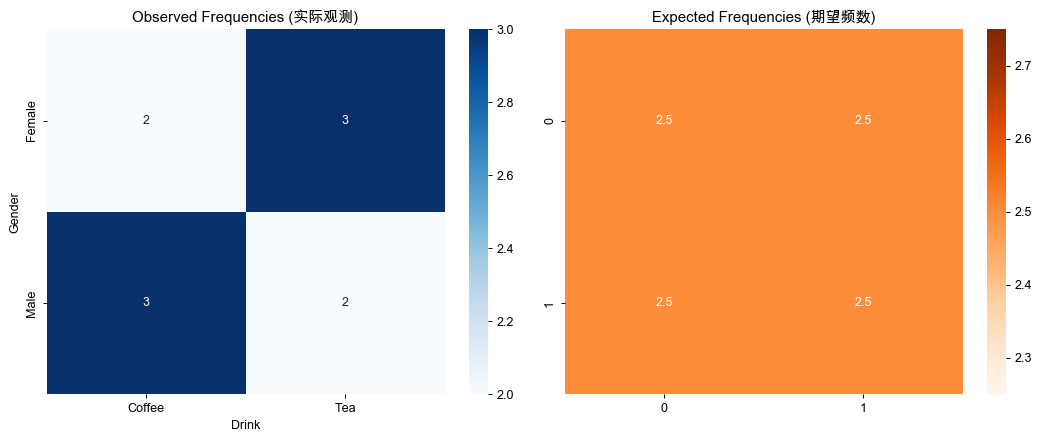

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 生成观测数据：性别 vs 饮品偏好
data = {'Gender': ['Male', 'Male', 'Male', 'Male', 'Male', 
                   'Female', 'Female', 'Female', 'Female', 'Female'],
        'Drink':  ['Coffee', 'Coffee', 'Coffee', 'Tea', 'Tea',
                   'Tea', 'Tea', 'Coffee', 'Coffee', 'Tea']}

# 转换成DataFrame
df = pd.DataFrame(data)

# 计算交叉表（列联表）
contingency_table = pd.crosstab(df['Gender'], df['Drink'])

# 打印交叉表
print("交叉表 (列联表):\n", contingency_table)

# 执行卡方检验
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"卡方统计量: {chi2}")
print(f"p值: {p}")
print(f"自由度: {dof}")
print("期望频数:\n", expected)

# 可视化：实际观测 vs 期望频数
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 实际观测频数的热力图
sns.heatmap(contingency_table, annot=True, cmap="Blues", ax=ax[0])
ax[0].set_title("Observed Frequencies (实际观测)")

# 期望频数的热力图
sns.heatmap(expected, annot=True, cmap="Oranges", ax=ax[1])
ax[1].set_title("Expected Frequencies (期望频数)")

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_012.png)

- **交叉表（列联表）**：`pd.crosstab` 函数用于生成两列分类变量的频数表。这个表格展示了各类别组合的观测频率，例如男性喜欢咖啡、女性喜欢茶的观测次数。
- **卡方检验**：`chi2_contingency` 函数计算卡方统计量、p值、自由度以及期望频数表。
- **可视化**：使用`seaborn.heatmap` 绘制实际观测频数和期望频数的热力图，帮助直观理解数据分布。

**3. 卡方检验的机器学习应用：特征选择**

在机器学习中，卡方检验可以用于**分类变量的特征选择**。在处理分类数据时，我们可以使用卡方检验筛选出对分类结果有影响的特征。接下来，展示如何在分类问题中应用卡方检验来选择特征。

应用场景：

我们有一组分类数据，其中包含特征`Gender`和`Purchase`（是否购买商品）。我们想用卡方检验来判断`Gender`是否对`Purchase`有显著影响。

In [4]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 假设有以下数据：性别、年龄、是否购买
data = {'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
        'Age': [25, 30, 45, 22, 35, 50, 23, 40, 29, 28],
        'Purchase': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No']}

df = pd.DataFrame(data)

# 对分类变量进行编码：Gender 和 Purchase
le_gender = LabelEncoder()
le_purchase = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])  # Male: 1, Female: 0
df['Purchase'] = le_purchase.fit_transform(df['Purchase'])  # Yes: 1, No: 0

# 定义特征和标签
X = df[['Gender', 'Age']]  # 特征：性别和年龄
y = df['Purchase']         # 标签：是否购买

# 使用卡方检验进行特征选择
chi2_selector = SelectKBest(chi2, k=1)  # 选择1个最相关的特征
X_kbest = chi2_selector.fit_transform(X, y)

# 输出被选择的特征
print("被选择的特征：", X.columns[chi2_selector.get_support()])

# 拆分数据并训练模型
X_train, X_test, y_train, y_test = train_test_split(X_kbest, y, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# 评估模型
accuracy = clf.score(X_test, y_test)
print(f"模型准确率: {accuracy:.2f}")

被选择的特征： Index(['Gender'], dtype='object')
模型准确率: 1.00


- **LabelEncoder**：用于将分类变量转换为数值型（如性别和购买情况分别编码为0和1）。
- **SelectKBest**：使用`SelectKBest`结合`chi2`函数执行卡方检验，从特征集中选择最相关的特征。
- **特征选择**：在这个例子中，我们用卡方检验筛选了一个对`Purchase`（是否购买）最有影响的特征，并将其用于模型训练。
- **模型训练**：我们使用决策树分类器训练和评估模型，并输出模型的准确率。

在代码中，通过`scipy.stats.chi2_contingency`，我们可以轻松执行卡方检验，分析分类变量之间的关联性。我们在机器学习任务中，卡方检验是一种有效的**特征选择工具**，帮助我们筛选出对目标变量影响最大的分类特征，从而提高模型的性能。